## Data Science Assignment: Employee Attrition Classification

Dataset: Employee.csv
Target Variable: LeaveOrNot (0 = stayed, 1 = left)
Objective
Predict whether an employee will leave the company using classification techniques.

## Part 1: Data Exploration

### 1. Load dataset and review its structure

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [109]:
df = pd.read_csv('Muhammad Zohaib - Employee.csv')

In [110]:
df.shape

(4653, 9)

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
 8   LeaveOrNot                 4653 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 327.3+ KB


In [112]:
df.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


### 2. Identify the categorical and numerical features.


In [113]:
categorical_data = df.select_dtypes(include=object).columns.tolist() #Catagorical Data

for columns in categorical_data:
    print(columns)
    print(df[columns].unique())


Education
['Bachelors' 'Masters' 'PHD']
City
['Bangalore' 'Pune' 'New Delhi']
Gender
['Male' 'Female']
EverBenched
['No' 'Yes']


In [114]:
numerical_data = df.select_dtypes(include=['int64','float64']).columns.tolist() #Numerical Data

for columns in numerical_data:
    print(columns)
    print(df[columns].unique())

JoiningYear
[2017 2013 2014 2016 2015 2012 2018]
PaymentTier
[3 1 2]
Age
[34 28 38 27 24 22 23 37 32 39 29 30 36 31 25 26 40 35 33 41]
ExperienceInCurrentDomain
[0 3 2 5 1 4 7 6]
LeaveOrNot
[0 1]


### 3. Check for missing values.


In [115]:
df.isnull().sum()


Education                    0
JoiningYear                  0
City                         0
PaymentTier                  0
Age                          0
Gender                       0
EverBenched                  0
ExperienceInCurrentDomain    0
LeaveOrNot                   0
dtype: int64

4. Compute summary statistics for numerical features (Age, PaymentTier, ExperienceInCurrentDomain).


In [116]:
df[numerical_data].describe()

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot
count,4653.000000,4653.000000,4653.000000,4653.000000,4653.000000
mean,2015.062970,2.698259,29.393295,2.905652,0.343864
std,1.863377,0.561435,4.826087,1.558240,0.475047
min,2012.000000,1.000000,22.000000,0.000000,0.000000
25%,2013.000000,3.000000,26.000000,2.000000,0.000000
50%,2015.000000,3.000000,28.000000,3.000000,0.000000
75%,2017.000000,3.000000,32.000000,4.000000,1.000000
max,2018.000000,3.000000,41.000000,7.000000,1.000000


5. Analyze the distribution of categorical features (Education, City, Gender, EverBenched).


Text(0.5, 1.0, 'EDUCATION Distribution')

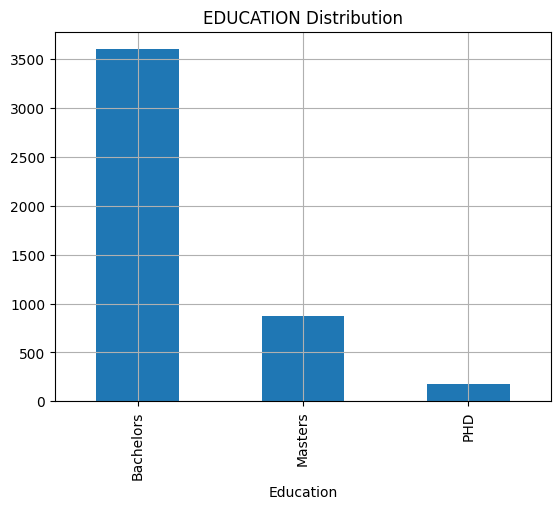

In [117]:
df[categorical_data[0]].value_counts().plot(kind='bar',grid=True)
plt.title(f'{categorical_data[0].upper()} Distribution')

Text(0.5, 1.0, 'CITY Distribution')

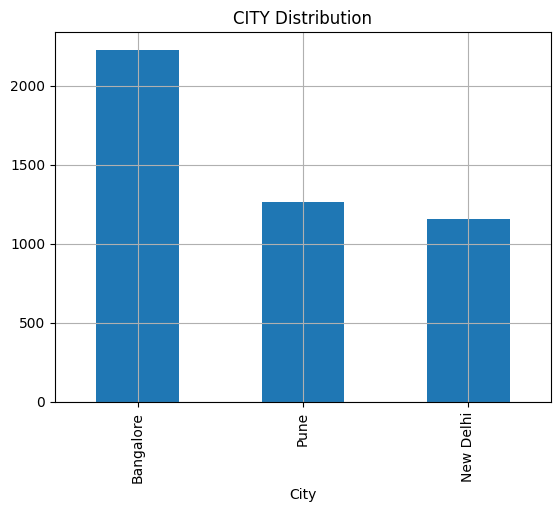

In [118]:
df[categorical_data[1]].value_counts().plot(kind='bar',grid=True)
plt.title(f'{categorical_data[1].upper()} Distribution')


Text(0.5, 1.0, 'GENDER Distribution')

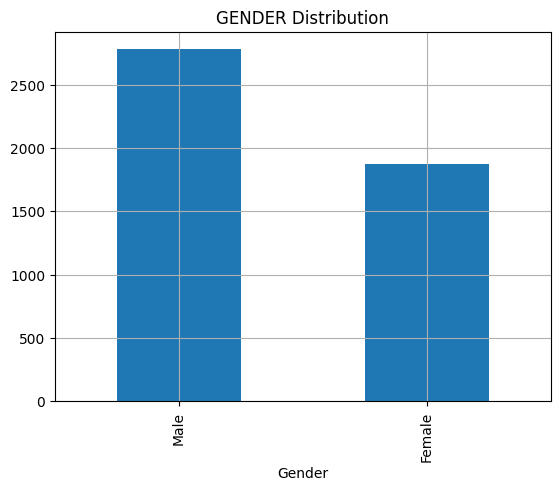

In [119]:
df[categorical_data[2]].value_counts().plot(kind='bar',grid=True)
plt.title(f'{categorical_data[2].upper()} Distribution')

Text(0.5, 1.0, 'EVERBENCHED Distribution')

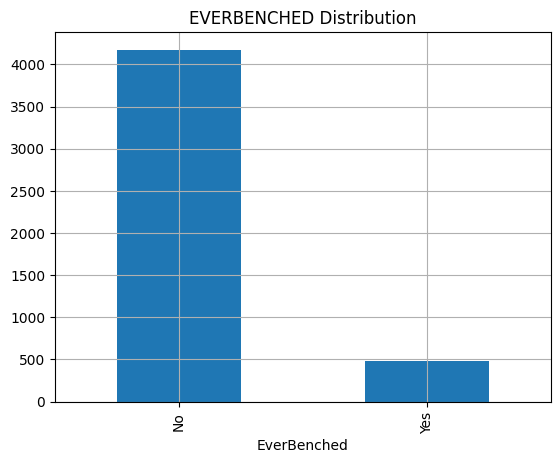

In [120]:
df[categorical_data[3]].value_counts().plot(kind='bar',grid=True)
plt.title(f'{categorical_data[3].upper()} Distribution')

6. Plot or visualize the distribution of the target variable LeaveOrNot.

<Axes: ylabel='count'>

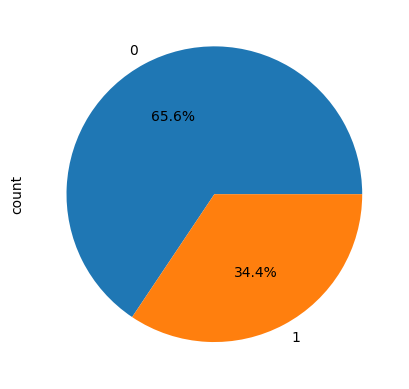

In [121]:
df["LeaveOrNot"].value_counts().plot(kind='pie',autopct='%1.1f%%')

## Part 2: Data Preprocessing

### 1. Encode categorical features (Education, City, Gender, EverBenched) appropriately.

In [122]:
education = pd.get_dummies(df['Education'],drop_first=True)
city = pd.get_dummies(df['City'],drop_first=True)
gender = pd.get_dummies(df['Gender'],drop_first=True)
everbench = pd.get_dummies(df['EverBenched'],drop_first=True)

In [ ]:
df=pd.concat([df,education,city,gender,everbench],axis=1)
df.head()



,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot,Masters,PHD,New Delhi,Pune,Male,Yes
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0,False,False,False,False,True,False
1,Bachelors,2013,Pune,1,28,Female,No,3,1,False,False,False,True,False,False
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0,False,False,True,False,False,False
3,Masters,2016,Bangalore,3,27,Male,No,5,1,True,False,False,False,True,False
4,Masters,2017,Pune,3,24,Male,Yes,2,1,True,False,False,True,True,True


In [124]:
df.drop(['Education','City','Gender','EverBenched'],axis=1,inplace=True)

In [125]:
df.head()

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot,Masters,PHD,New Delhi,Pune,Male,Yes
0,2017,3,34,0,0,False,False,False,False,True,False
1,2013,1,28,3,1,False,False,False,True,False,False
2,2014,3,38,2,0,False,False,True,False,False,False
3,2016,3,27,5,1,True,False,False,False,True,False
4,2017,3,24,2,1,True,False,False,True,True,True


In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   JoiningYear                4653 non-null   int64
 1   PaymentTier                4653 non-null   int64
 2   Age                        4653 non-null   int64
 3   ExperienceInCurrentDomain  4653 non-null   int64
 4   LeaveOrNot                 4653 non-null   int64
 5   Masters                    4653 non-null   bool 
 6   PHD                        4653 non-null   bool 
 7   New Delhi                  4653 non-null   bool 
 8   Pune                       4653 non-null   bool 
 9   Male                       4653 non-null   bool 
 10  Yes                        4653 non-null   bool 
dtypes: bool(6), int64(5)
memory usage: 209.1 KB


### 2. Handle scaling of numerical features if needed (Age, ExperienceInCurrentDomain, JoiningYear, PaymentTier).

In [131]:
x = df.drop('LeaveOrNot', axis = 1)
y = df['LeaveOrNot']

In [132]:
print(x.shape)
print(y.shape)

(4653, 10)
(4653,)


In [134]:
from sklearn import preprocessing
pre_process = preprocessing.StandardScaler().fit(x)
x_transform = pre_process.fit_transform(x)

In [135]:
x_transform

array([[ 1.03963837,  0.53750299,  0.95464513, ..., -0.61204068,
         0.82155097, -0.33836521],
       [-1.10723275, -3.0251771 , -0.28873172, ...,  1.63387832,
        -1.21720992, -0.33836521],
       [-0.57051497,  0.53750299,  1.78356303, ..., -0.61204068,
        -1.21720992, -0.33836521],
       ...,
       [ 1.57635615,  0.53750299, -0.49596119, ..., -0.61204068,
         0.82155097, -0.33836521],
       [-1.64395053,  0.53750299,  0.12572723, ..., -0.61204068,
         0.82155097,  2.95538654],
       [-0.03379719,  0.53750299,  0.74741565, ..., -0.61204068,
         0.82155097,  2.95538654]])

### 3. Split the dataset into training and testing sets (suggested: 80%-20%).

In [136]:
# Use x and y variables to split the training data into train and test set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = .20, random_state = 42)

In [137]:
print(f"Total samples  : {len(x)}")
print(f"Training set   : {len(x_train)} samples ({len(x_train)/len(x)*100:.0f}%)")
print(f"Test set       : {len(x_test)} samples ({len(x_test)/len(x)*100:.0f}%)")

Total samples  : 4653
Training set   : 3722 samples (80%)
Test set       : 931 samples (20%)


---
## Part 3: Model Building

### 1. Decision Tree Classifier

In [140]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
dt_model = DecisionTreeClassifier(
    max_depth=5, min_samples_split=20,
    min_samples_leaf=10, random_state=42
)
dt_model.fit(x_train, y_train)

print("Decision Tree trained successfully!")
print(f"Tree depth   : {dt_model.get_depth()}")
print(f"Leaf nodes   : {dt_model.get_n_leaves()}")
print(f"Features used: {x.columns.tolist()}")

Decision Tree trained successfully!
Tree depth   : 5
Leaf nodes   : 18
Features used: ['JoiningYear', 'PaymentTier', 'Age', 'ExperienceInCurrentDomain', 'Masters', 'PHD', 'New Delhi', 'Pune', 'Male', 'Yes']


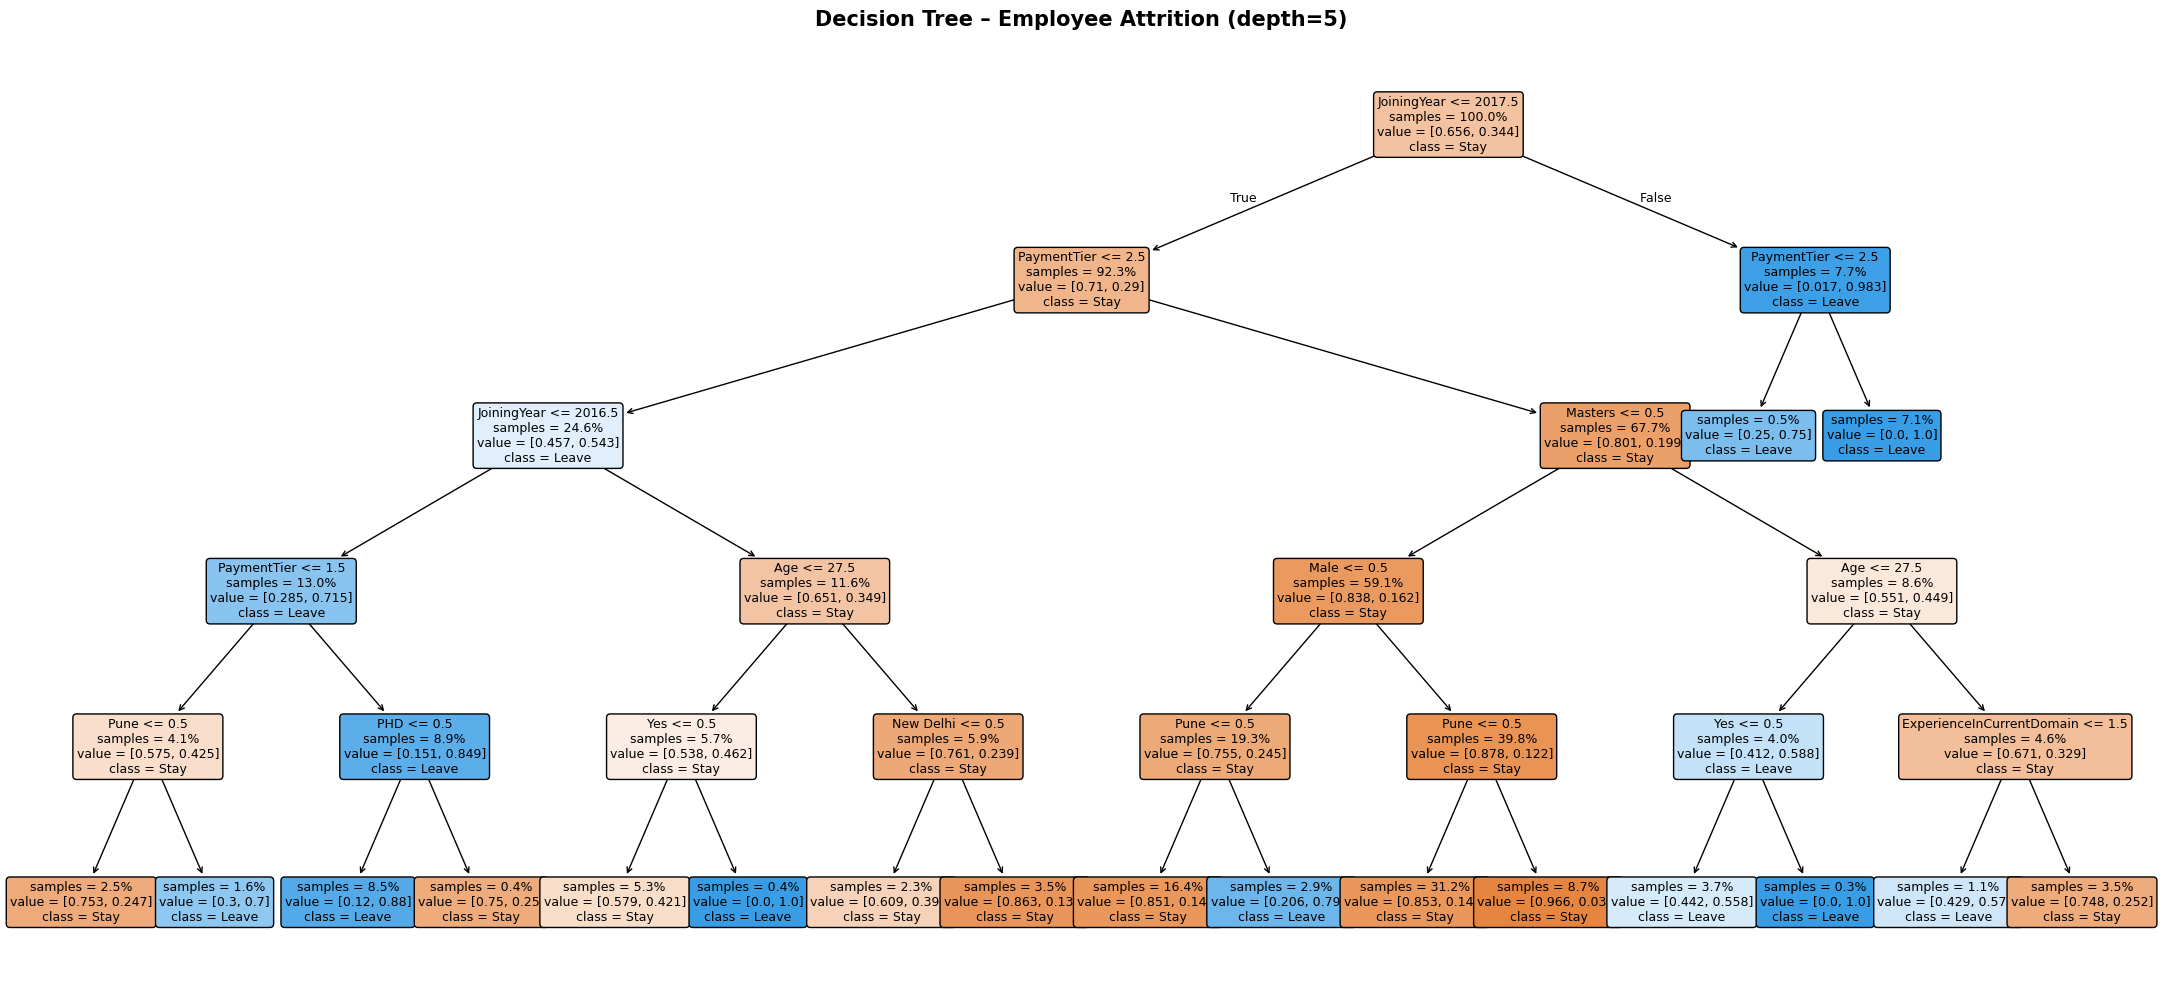

Tree visualisation saved.


In [142]:
# Visualise the tree
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt_model, feature_names=x.columns.tolist(),
    class_names=['Stay','Leave'], filled=True,
    rounded=True, fontsize=9, ax=ax, impurity=False, proportion=True
)
ax.set_title('Decision Tree – Employee Attrition (depth=5)', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('decision_tree.png', bbox_inches='tight')
plt.show()
print("Tree visualisation saved.")

### 2. Random Forest Classifier

In [144]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    min_samples_split=15, min_samples_leaf=5,
    random_state=42, n_jobs=-1
)
rf_model.fit(x_train, y_train)

print("Random Forest trained successfully!")
print(f"Number of trees : {rf_model.n_estimators}")
print(f"Max depth       : {rf_model.max_depth}")

Random Forest trained successfully!
Number of trees : 200
Max depth       : 10


### 3. Logistic Regression (Optional Comparison)

In [146]:
from sklearn.linear_model import LogisticRegression

print('Logistic Regression')
# Create instance of model
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Pass training data into model
log_reg.fit(x_train, y_train)

Logistic Regression


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


---
## Part 4: Model Evaluation

In [147]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [148]:
# Predictions
dt_pred = dt_model.predict(x_test)
rf_pred = rf_model.predict(x_test)
lr_pred = log_reg.predict(x_test)

# Accuracy
dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)
lr_acc = accuracy_score(y_test, lr_pred)

print("=" * 50)
print("         MODEL ACCURACY COMPARISON")
print("=" * 50)
print(f"  Decision Tree       : {dt_acc*100:.2f}%")
print(f"  Random Forest       : {rf_acc*100:.2f}%")
print(f"  Logistic Regression : {lr_acc*100:.2f}%")
print("=" * 50)
best = max([(dt_acc,'Decision Tree'),(rf_acc,'Random Forest'),(lr_acc,'Logistic Regression')], key=lambda x:x[0])
print(f"  Best model: {best[1]} ({best[0]*100:.2f}%)")

         MODEL ACCURACY COMPARISON
  Decision Tree       : 85.28%
  Random Forest       : 86.90%
  Logistic Regression : 74.44%
  Best model: Random Forest (86.90%)


In [149]:
# Detailed classification reports
models = {
    'Decision Tree'       : (dt_model, dt_pred),
    'Random Forest'       : (rf_model, rf_pred),
    'Logistic Regression' : (log_reg, lr_pred)
}

for name, (model, pred) in models.items():
    print(f"\n{'='*55}")
    print(f"  {name}")
    print('='*55)
    print(classification_report(y_test, pred, target_names=['Stay','Leave']))


  Decision Tree
              precision    recall  f1-score   support

        Stay       0.85      0.94      0.89       610
       Leave       0.87      0.68      0.76       321

    accuracy                           0.85       931
   macro avg       0.86      0.81      0.83       931
weighted avg       0.85      0.85      0.85       931


  Random Forest
              precision    recall  f1-score   support

        Stay       0.85      0.97      0.91       610
       Leave       0.93      0.67      0.78       321

    accuracy                           0.87       931
   macro avg       0.89      0.82      0.84       931
weighted avg       0.88      0.87      0.86       931


  Logistic Regression
              precision    recall  f1-score   support

        Stay       0.76      0.90      0.82       610
       Leave       0.70      0.45      0.55       321

    accuracy                           0.74       931
   macro avg       0.73      0.68      0.69       931
weighted avg     

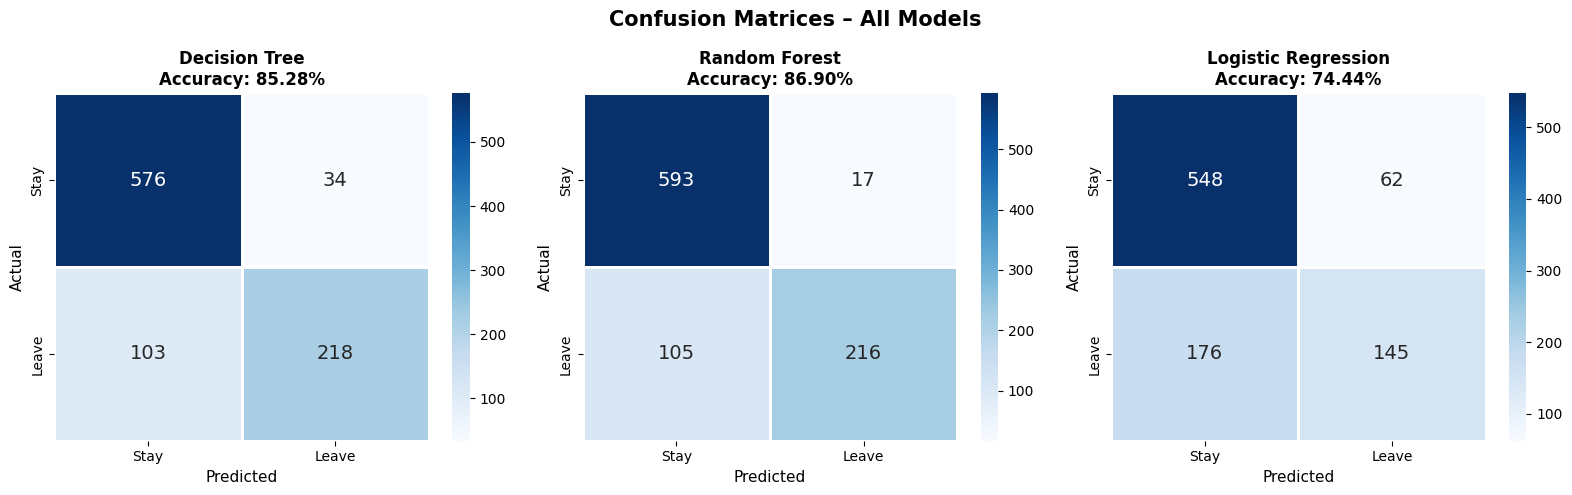

In [150]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrices – All Models', fontsize=15, fontweight='bold')

cmap = 'Blues'
for ax, (name, (_, pred)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Stay','Leave'], yticklabels=['Stay','Leave'],
                linewidths=1, linecolor='white', annot_kws={'size':14})
    acc = accuracy_score(y_test, pred)
    ax.set_title(f'{name}\nAccuracy: {acc*100:.2f}%', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

---
## Part 5: Analysis Questions
### Q1: Which Features Are Most Important in Predicting Employee Attrition?

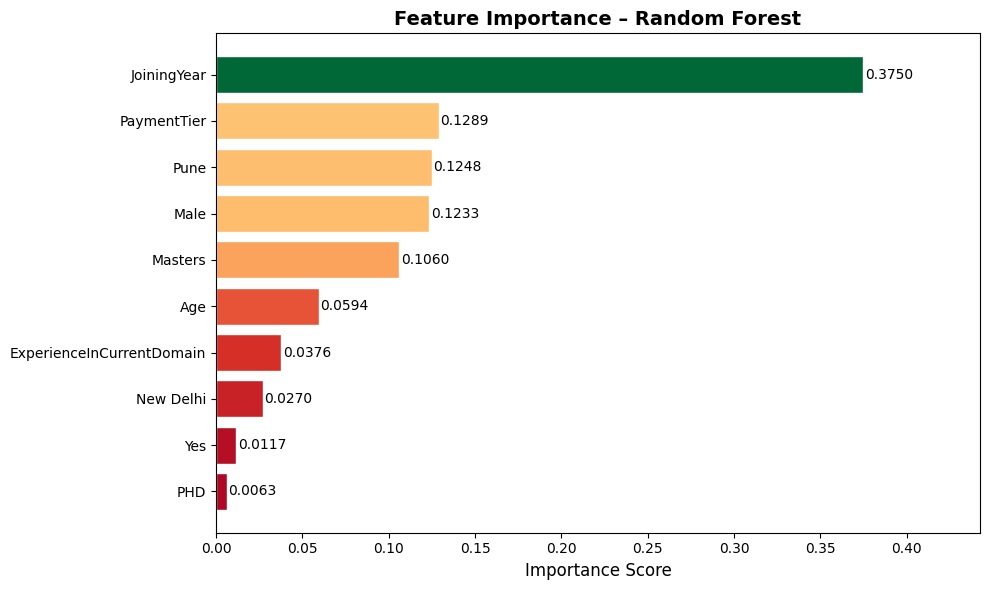

Feature Importance Ranking:
  JoiningYear                   : 0.3750  (37.50%)
  PaymentTier                   : 0.1289  (12.89%)
  Pune                          : 0.1248  (12.48%)
  Male                          : 0.1233  (12.33%)
  Masters                       : 0.1060  (10.60%)
  Age                           : 0.0594  (5.94%)
  ExperienceInCurrentDomain     : 0.0376  (3.76%)
  New Delhi                     : 0.0270  (2.70%)
  Yes                           : 0.0117  (1.17%)
  PHD                           : 0.0063  (0.63%)


In [154]:
# Random Forest feature importances
importances = pd.Series(rf_model.feature_importances_, index=x.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importances.index, importances.values,
               color=plt.cm.RdYlGn(importances.values / importances.max()),
               edgecolor='white')
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Feature Importance – Random Forest', fontsize=14, fontweight='bold')
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
ax.set_xlim(0, importances.max() * 1.18)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

print("Feature Importance Ranking:")
for feat, imp in importances.sort_values(ascending=False).items():
    print(f"  {feat:30s}: {imp:.4f}  ({imp*100:.2f}%)")

In [157]:
# Decision Tree feature importances (comparison)
dt_imp = pd.Series(dt_model.feature_importances_, index=x.columns).sort_values(ascending=False)
print("Decision Tree Feature Importances:")
for feat, imp in dt_imp.items():
    print(f"  {feat:30s}: {imp:.4f}")

Decision Tree Feature Importances:
  JoiningYear                   : 0.4298
  PaymentTier                   : 0.2727
  Pune                          : 0.1329
  Masters                       : 0.0628
  Age                           : 0.0293
  Male                          : 0.0201
  Yes                           : 0.0178
  PHD                           : 0.0165
  New Delhi                     : 0.0092
  ExperienceInCurrentDomain     : 0.0089


### Q2: How Do Age and ExperienceInCurrentDomain Affect the Likelihood of Leaving?

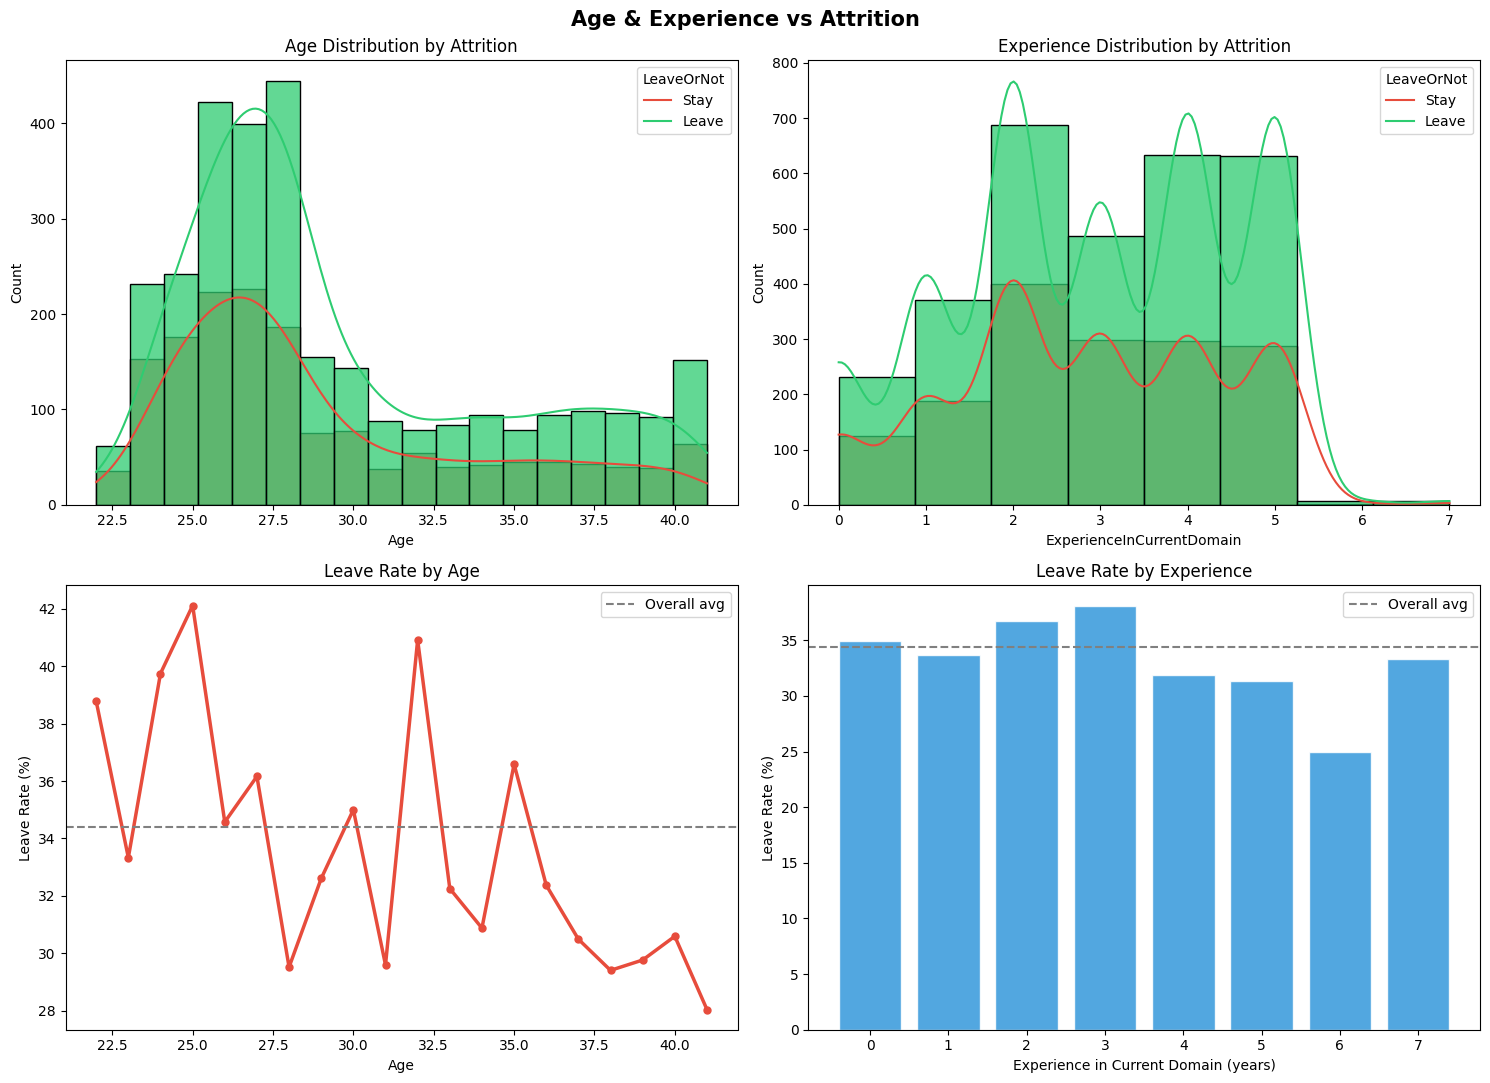

In [158]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Age & Experience vs Attrition', fontsize=15, fontweight='bold')
palette = {0: '#2ecc71', 1: '#e74c3c'}

# Age distribution by LeaveOrNot
sns.histplot(data=df, x='Age', hue='LeaveOrNot', kde=True, bins=18,
             palette=palette, ax=axes[0,0], alpha=0.75)
axes[0,0].set_title('Age Distribution by Attrition')
axes[0,0].legend(['Stay','Leave'], title='LeaveOrNot')

# Experience distribution
sns.histplot(data=df, x='ExperienceInCurrentDomain', hue='LeaveOrNot', kde=True,
             bins=8, palette=palette, ax=axes[0,1], alpha=0.75)
axes[0,1].set_title('Experience Distribution by Attrition')
axes[0,1].legend(['Stay','Leave'], title='LeaveOrNot')

# Age vs leave rate
age_leave = df.groupby('Age')['LeaveOrNot'].mean().reset_index()
axes[1,0].plot(age_leave['Age'], age_leave['LeaveOrNot']*100,
               color='#e74c3c', linewidth=2.5, marker='o', markersize=5)
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Leave Rate (%)')
axes[1,0].set_title('Leave Rate by Age')
axes[1,0].axhline(df['LeaveOrNot'].mean()*100, color='gray', linestyle='--', label='Overall avg')
axes[1,0].legend()

# Experience vs leave rate
exp_leave = df.groupby('ExperienceInCurrentDomain')['LeaveOrNot'].mean().reset_index()
axes[1,1].bar(exp_leave['ExperienceInCurrentDomain'], exp_leave['LeaveOrNot']*100,
              color='#3498db', alpha=0.85, edgecolor='white')
axes[1,1].set_xlabel('Experience in Current Domain (years)')
axes[1,1].set_ylabel('Leave Rate (%)')
axes[1,1].set_title('Leave Rate by Experience')
axes[1,1].axhline(df['LeaveOrNot'].mean()*100, color='gray', linestyle='--', label='Overall avg')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('age_experience_analysis.png', bbox_inches='tight')
plt.show()